In [1]:
# import sys
# import os
# import warnings
# import uuid

# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# if project_root not in sys.path:
#     sys.path.append(project_root)

# warnings.filterwarnings("ignore")
# from agents.primary.agent import primary_graph 
import uuid
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import hàm build graph thay vì import graph trực tiếp
# from agents.hotel.agent import hotel_graph as graph 
from agents.primary.agent import build_primary_graph 
from utils.tracing import with_trace_config

# Khởi tạo graph (cần dùng await vì hàm này là async)
graph = await build_primary_graph()

c:\Program Files\Python312\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


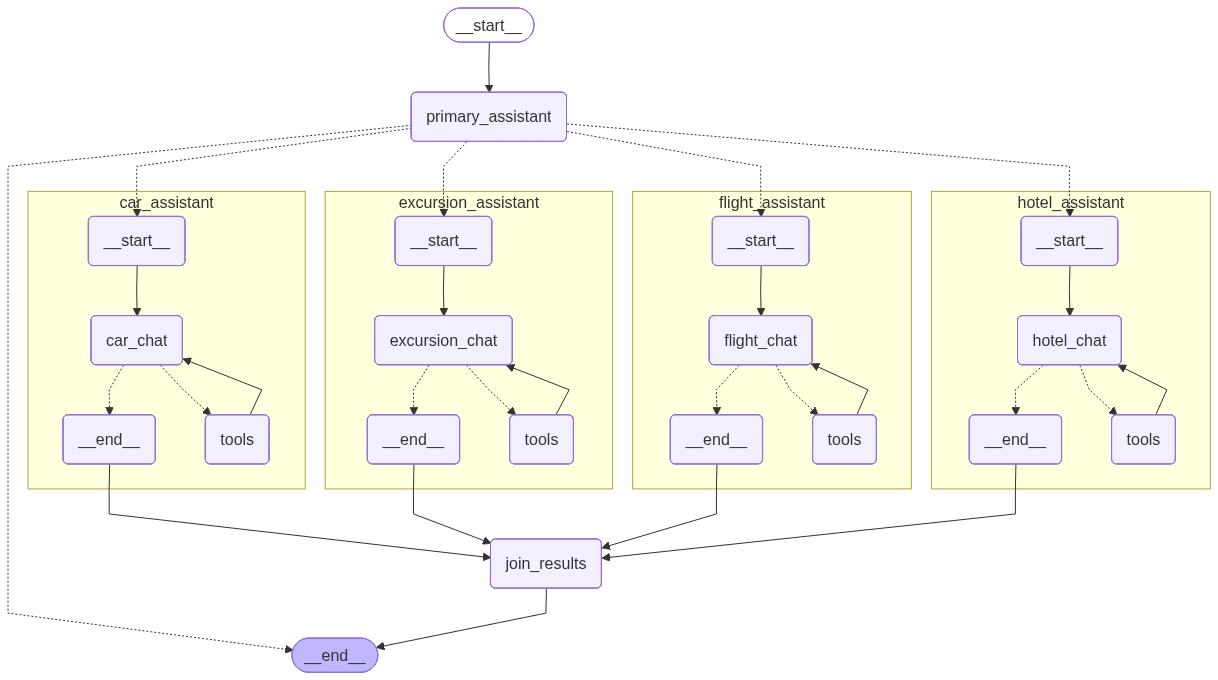

In [2]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
_printed = set()

def _print_event(event: dict, _printed: set, max_length=5000):
    messages = event.get("messages")
    if not messages:
        return

    if not isinstance(messages, list):
        messages = [messages]

    for message in messages:
        message_id = getattr(message, "id", None)
        if message_id in _printed:
            continue

        msg_repr = message.pretty_repr(html=True)
        if len(msg_repr) > max_length:
            msg_repr = msg_repr[:max_length] + " ... (truncated)"
        print(msg_repr)
        if message_id:
            _printed.add(message_id)

In [4]:
tutorial_questions = [
    "Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.",
]

thread_id = str(uuid.uuid4())
passenger_id = "8149 604011"  # ID hành khách (có thể thay đổi để test)

config = with_trace_config(
    {
        "configurable": {
            "passenger_id": passenger_id,
            "thread_id": thread_id,
        }
    },
    run_name="primary_agent_notebook",
    tags=["customer-support", "primary", "notebook"],
    metadata={"thread_id": thread_id, "passenger_id": passenger_id},
)

for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    async for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (5da43d86-aa67-4e74-b49e-6a88a04029fe)
 Call ID: 5da43d86-aa67-4e74-b49e-6a88a04029fe
  Args:
    request: Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.
================================= Tool Message =================================

Dưới đây là một số khách sạn ở Hà Nội có sẵn từ ngày 20/07/2026 đến 25/07/2026:

*   **Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội**
    *   ID: 16805122
    *   Giá: 4249995 VND
    *   Đánh giá: 10/10 (Xuất sắc)
    *   ![Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội](https://cf.bstatic.com/xdata/images/hotel/square500/891185217.jpg?k=99786eb3ff722fa98ac2cff2fd49315577f0f387fd2329ad4d3321bf8d8f20f4&o=)

*   **The Urbanist - Hanoi Pool Oasis**
    *   ID: 16795752
    *   G

In [5]:
tutorial_questions = [
    " Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026. tôi muốn kiếm trip ở Đà Nẵng ngày 30/8/2026 ",
]

thread_id = str(uuid.uuid4())
passenger_id = "8149 604011"  # ID hành khách (có thể thay đổi để test)

config = with_trace_config(
    {
        "configurable": {
            "passenger_id": passenger_id,
            "thread_id": thread_id,
        }
    },
    run_name="primary_agent_notebook_multi_domain",
    tags=["customer-support", "primary", "notebook", "multi-domain"],
    metadata={"thread_id": thread_id, "passenger_id": passenger_id},
)

for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    async for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

 Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026. tôi muốn kiếm trip ở Đà Nẵng ngày 30/8/2026 
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (60a0d9ad-4913-4b36-9923-8172b35e82dd)
 Call ID: 60a0d9ad-4913-4b36-9923-8172b35e82dd
  Args:
    request: Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.
  ToExcursionAssistant (855ed318-ba82-48bb-9d60-3d22e9d9ab68)
 Call ID: 855ed318-ba82-48bb-9d60-3d22e9d9ab68
  Args:
    request: Tìm kiếm chuyến đi ở Đà Nẵng ngày 30/8/2026.
================================= Tool Message =================================

Dưới đây là các khách sạn ở Hà Nội có phòng trống từ ngày 20/07/2026 đến 25/07/2026:

*   **Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội**
    *   ID: 16805122
    *   Giá: 4.249.995 VND
    *   Đánh giá: 10/10 (Xuất sắc)
    *   ![Lakenest Realty 21, Âu 